# 02.Neural network with pytorch
### classification is a problem of predicting whether something is one thing or another

In [1]:
import sklearn 
from sklearn.datasets import make_circles
# making samples
n_samples = 1000
X,y = make_circles(n_samples,noise=0.03,random_state=42)


In [2]:
len(X),len(y)

(1000, 1000)

In [3]:
#exploring the created dataset
print(f"First 5 Samples of X:\n : {X[:5]}")
print(f"First 5 Samples of y:\n : {y[:5]}")

First 5 Samples of X:
 : [[ 0.75424625  0.23148074]
 [-0.75615888  0.15325888]
 [-0.81539193  0.17328203]
 [-0.39373073  0.69288277]
 [ 0.44220765 -0.89672343]]
First 5 Samples of y:
 : [1 1 1 1 0]


In [4]:
#Making a dataframe of the circle data
import pandas as pd
circles = pd.DataFrame({"X1":X[:,0] ,"X2":X[:,1], "label":y})

circles.head(10)


,X1,X2,label
0,0.754246,0.231481,1
1,-0.756159,0.153259,1
2,-0.815392,0.173282,1
3,-0.393731,0.692883,1
4,0.442208,-0.896723,0
5,-0.479646,0.676435,1
6,-0.013648,0.803349,1
7,0.771513,0.147760,1
8,-0.169322,-0.793456,1
9,-0.121486,1.021509,0


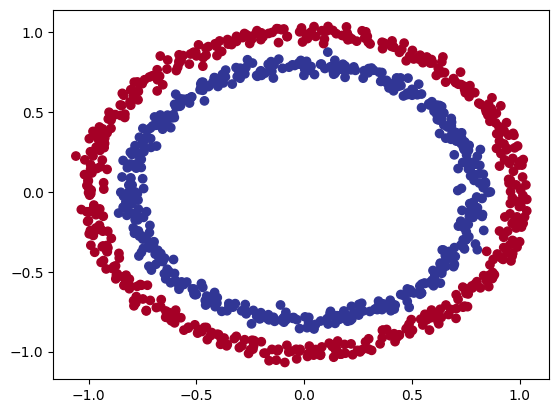

In [5]:
#Visualizing using matplotlib to get an idea of the data 
import matplotlib.pyplot as plt
plt.scatter(x=X[:,0],y=X[:,1],c=y,cmap=plt.cm.RdYlBu)

1.1 Check input and output shapes

In [6]:
X.shape,y.shape

((1000, 2), (1000,))

In [7]:
# View the first example of features and labels
X_sample = X[0]
y_sample = y[0]
 
print(f"Values for one sample of X : {X_sample} , Y sample : {y_sample}")
print(f"Values for one sample of X : {X_sample.shape} , Y sample : {y_sample.shape}")


Values for one sample of X : [0.75424625 0.23148074] , Y sample : 1
Values for one sample of X : (2,) , Y sample : ()


### 1.2 Turning the data into tesnors and train and test splits


In [8]:
# turn data into tensors
import torch
X = torch.from_numpy(X).type(torch.float)
y = torch.from_numpy(y).type(torch.float) 
X[:5],y[:5]

(tensor([[ 0.7542,  0.2315],
         [-0.7562,  0.1533],
         [-0.8154,  0.1733],
         [-0.3937,  0.6929],
         [ 0.4422, -0.8967]]),
 tensor([1., 1., 1., 1., 0.]))

In [9]:
#Split data into test and train
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)


In [10]:
len(X_train) , len(y_train) ,len(X_test) , len(y_test)

(800, 800, 200, 200)

In [11]:
n_samples

1000

## 2.Building a model
1.Setup device agnostic code

2.Construct a model

3.Define a loss function and an optimizer

4.Create a training and testing loop



In [12]:
import torch
from torch import nn
device =  "cuda" if torch.cuda.is_available() else "cpu" 
device

'cuda'

1.Subclass torch.nn.module

2.define a forward() method

3. initiate an instance and send it to the target device

In [13]:
#Creating a subclass of nn.Module
class CircleModelv0(nn.Module):
    def __init__(self):
        super().__init__()
    #Create 2 nn.layers capable of hanling the input data 
        self.layer_1 = nn.Linear(in_features = 2, out_features = 5) #Takses 2 features and upscales it to 5

        self.layer_2 = nn.Linear(in_features = 5 , out_features = 1) #Takes inputs from layer_1 and outputs 1 feature
    #Defining a forward pass
    def forward(self,x):
        return self.layer_2(self.layer_1(x)) # x goes into layer 1 first and then layer 2 
#inittiate the model and send it to the target device
model_0 = CircleModelv0().to(device)
model_0


CircleModelv0(
  (layer_1): Linear(in_features=2, out_features=5, bias=True)
  (layer_2): Linear(in_features=5, out_features=1, bias=True)
)

In [14]:
model_0.state_dict()

OrderedDict([('layer_1.weight',
              tensor([[ 0.3459,  0.3244],
                      [ 0.1319,  0.4470],
                      [-0.3389,  0.7048],
                      [ 0.2776, -0.2405],
                      [ 0.3178,  0.4518]], device='cuda:0')),
             ('layer_1.bias',
              tensor([ 0.5275, -0.0642, -0.3269,  0.1603,  0.0632], device='cuda:0')),
             ('layer_2.weight',
              tensor([[ 0.0173,  0.0308,  0.0899,  0.2777, -0.0205]], device='cuda:0')),
             ('layer_2.bias', tensor([-0.0987], device='cuda:0'))])

In [15]:
#Replicating the aobve model using torch.sequential

model_0 = nn.Sequential(nn.Linear(in_features= 2,out_features=5),
                        nn.Linear(in_features = 5,out_features = 1)
                            ).to(device)

model_0

Sequential(
  (0): Linear(in_features=2, out_features=5, bias=True)
  (1): Linear(in_features=5, out_features=1, bias=True)
)

In [16]:
model_0.state_dict()

OrderedDict([('0.weight',
              tensor([[-0.0928, -0.3133],
                      [-0.0244,  0.1506],
                      [ 0.6478, -0.2485],
                      [-0.6185,  0.0245],
                      [ 0.5129,  0.7046]], device='cuda:0')),
             ('0.bias',
              tensor([ 0.6709, -0.2349, -0.3515, -0.4850, -0.1042], device='cuda:0')),
             ('1.weight',
              tensor([[-0.2938, -0.2046, -0.2739,  0.0196, -0.1331]], device='cuda:0')),
             ('1.bias', tensor([0.0745], device='cuda:0'))])

In [17]:
#Making precitions with the model
with torch.inference_mode():
    untrained_preds = model_0(X_test.to(device))
    print(f"Length of predictions {len(untrained_preds)},Shape of predictions {untrained_preds.shape}")
    print(f"Length of test samples :{len(X_test)} , {len(y_test)}")
    print(f"First 10 predictions: \n {untrained_preds[:10]}")
    print(f"First 10 labels : \n  {y_test[:10]}")

Length of predictions 200,Shape of predictions torch.Size([200, 1])
Length of test samples :200 , 200
First 10 predictions: 
 tensor([[ 0.1353],
        [ 0.0572],
        [ 0.1733],
        [ 0.1252],
        [-0.0915],
        [-0.1371],
        [-0.1473],
        [-0.1934],
        [ 0.1844],
        [ 0.0490]], device='cuda:0')
First 10 labels : 
  tensor([1., 0., 1., 0., 1., 1., 0., 0., 1., 0.])


In [18]:
X_test[:10]

tensor([[-0.3752,  0.6827],
        [ 0.0154,  0.9600],
        [-0.7028, -0.3147],
        [-0.2853,  0.9664],
        [ 0.4024, -0.7438],
        [ 0.6323, -0.5711],
        [ 0.8561,  0.5499],
        [ 1.0034,  0.1903],
        [-0.7489, -0.2951],
        [ 0.0538,  0.9739]])

In [19]:
y_test[:10]

tensor([1., 0., 1., 0., 1., 1., 0., 0., 1., 0.])

### 2.1 Loss fucntion and optimizer
Selecting a loss fucntion and an optimzier depends on the kinf od problem you are trying to solve.

for prediction we use MAE or MSE 
for classification we use binary cross entropy or categorical cross entropy


In [20]:
#Setup the loss fucntion
# loss_fn = nn.BCELoss() = requires inputs to have gone through a sigmoid activation function
#nn.Sequential(
    #nn.sigmoid(),
    #nn.BCELoss()

#)
loss_fn = nn.BCEWithLogitsLoss()
optimizer = torch.optim.SGD(params=model_0.parameters(),
                            lr = 0.1)

In [21]:
model_0.state_dict()

OrderedDict([('0.weight',
              tensor([[-0.0928, -0.3133],
                      [-0.0244,  0.1506],
                      [ 0.6478, -0.2485],
                      [-0.6185,  0.0245],
                      [ 0.5129,  0.7046]], device='cuda:0')),
             ('0.bias',
              tensor([ 0.6709, -0.2349, -0.3515, -0.4850, -0.1042], device='cuda:0')),
             ('1.weight',
              tensor([[-0.2938, -0.2046, -0.2739,  0.0196, -0.1331]], device='cuda:0')),
             ('1.bias', tensor([0.0745], device='cuda:0'))])

In [22]:
# calculating arruracy
def accuracy_fn(y_true,y_pred):
    correct = torch.eq(y_true,y_pred).sum().item()
    acc = (correct / len(y_pred)) * 100
    return acc 

### 3. Training the model
training loop:

1.Forward pass

2. Calculate the loss

3. optimize using zero grad

4.Back propogation

5.optimizer step(gradient descent)

#### Going from raw logits -> prediction probabilities ->prediction labels

i.e the model is going to output raw **logits** 

we can convert these **logits** into prediction probabilities using an activation function

In [23]:
#viewin the first 5 outputs
model_0.eval()
with torch.inference_mode():
    y_logits = model_0(X_test.to(device))[:5]
y_logits

tensor([[ 0.1353],
        [ 0.0572],
        [ 0.1733],
        [ 0.1252],
        [-0.0915]], device='cuda:0')

In [24]:
model_0.state_dict()

OrderedDict([('0.weight',
              tensor([[-0.0928, -0.3133],
                      [-0.0244,  0.1506],
                      [ 0.6478, -0.2485],
                      [-0.6185,  0.0245],
                      [ 0.5129,  0.7046]], device='cuda:0')),
             ('0.bias',
              tensor([ 0.6709, -0.2349, -0.3515, -0.4850, -0.1042], device='cuda:0')),
             ('1.weight',
              tensor([[-0.2938, -0.2046, -0.2739,  0.0196, -0.1331]], device='cuda:0')),
             ('1.bias', tensor([0.0745], device='cuda:0'))])

In [25]:
#use the sigmoid activation function on the logits
y_preds_probs = torch.sigmoid(y_logits)
y_preds_probs

tensor([[0.5338],
        [0.5143],
        [0.5432],
        [0.5313],
        [0.4771]], device='cuda:0')

In [26]:
torch.round(y_preds_probs)

tensor([[1.],
        [1.],
        [1.],
        [1.],
        [0.]], device='cuda:0')

y_logits --> y_logits.round() **incorrect** 

y_logits --> y_pred_probs = torch.sigmoid(y_logits) --> torch.round(y_preds_probs) **correct**

for prediction probability values, we need to perform a range-style rounding on them:

**'y_pred_probs' >=0.5,'y = 1' (class = 1)** 

**'y_pred_probs < 0.5 , 'y = 0 (class = 0)**

In [27]:
# finding the predicted labels
y_preds = torch.round(y_preds_probs)
# In full
y_pred_labels = torch.round(torch.sigmoid(model_0(X_test.to(device))[:5]))
#check for equality
print(torch.eq(y_preds.squeeze(),y_pred_labels.squeeze()))
#get rid of extra dimension
y_preds.squeeze()

tensor([True, True, True, True, True], device='cuda:0')


tensor([1., 1., 1., 1., 0.], device='cuda:0')

In [28]:
y_test[:5]

tensor([1., 0., 1., 0., 1.])

## 3.2 Building a training and a testing loop

In [29]:
device

'cuda'

In [30]:
X_train,y_train = X_train.to(device), y_train.to(device)
X_test,y_test = X_test.to(device), y_test.to(device)

In [31]:

#Put the model to target device
model_0.to(device)


torch.cuda.manual_seed(42)
torch.manual_seed(42)
#set the number of epochs
epochs = 1000
#Put the data to the target device
X_train,y_train = X_train.to(device), y_train.to(device)
X_test,y_test = X_test.to(device), y_test.to(device)

#Building training and evalution loop
for epoch in range(epochs):
    model_0.train()

    #1.Forward pass
    y_logits = model_0(X_train).squeeze()
    y_pred = torch.round(torch.sigmoid(y_logits)) # turn logits - >pred probs -> pred labels
    loss = loss_fn(y_logits,#nn.BCEWithLogitLoss expects raw logits as input 
                    y_train)

    acc = accuracy_fn(y_true = y_train,y_pred = y_pred)
    #Optimizer zero grad
    optimizer.zero_grad()
    #Loss backward(backpropogation)
    loss.backward()
    #Optimizer step
    optimizer.step()
    #Testing
    model_0.eval()
    with torch.inference_mode():
        #Forward pass
        test_logits = model_0(X_test).squeeze()
        test_pred = torch.round(torch.sigmoid(test_logits))

        #Caculate the test loss/ acc
        test_loss = loss_fn(test_logits,
                            y_test)
        
        test_acc = accuracy_fn(y_true=y_test,y_pred = test_pred)
        
        #Printing out what is happening in the training loop
        if epoch % 10 == 0:
            print(f"Epochs | {epoch}|loss : {loss:.5f}|Acc:{acc:.2f}%|Test loss : {test_loss:.5f} | Test accuracy{test_acc:.2f}%")

Epochs | 0|loss : 0.69626|Acc:50.88%|Test loss : 0.69415 | Test accuracy50.00%
Epochs | 10|loss : 0.69544|Acc:50.38%|Test loss : 0.69396 | Test accuracy48.50%
Epochs | 20|loss : 0.69486|Acc:50.25%|Test loss : 0.69388 | Test accuracy48.00%
Epochs | 30|loss : 0.69443|Acc:50.25%|Test loss : 0.69388 | Test accuracy50.50%
Epochs | 40|loss : 0.69410|Acc:49.88%|Test loss : 0.69391 | Test accuracy51.50%
Epochs | 50|loss : 0.69385|Acc:49.88%|Test loss : 0.69397 | Test accuracy51.50%
Epochs | 60|loss : 0.69366|Acc:49.50%|Test loss : 0.69404 | Test accuracy54.00%
Epochs | 70|loss : 0.69351|Acc:50.00%|Test loss : 0.69411 | Test accuracy52.00%
Epochs | 80|loss : 0.69340|Acc:49.50%|Test loss : 0.69418 | Test accuracy51.50%
Epochs | 90|loss : 0.69331|Acc:50.00%|Test loss : 0.69425 | Test accuracy49.50%
Epochs | 100|loss : 0.69324|Acc:50.50%|Test loss : 0.69432 | Test accuracy51.00%
Epochs | 110|loss : 0.69318|Acc:50.12%|Test loss : 0.69438 | Test accuracy51.00%
Epochs | 120|loss : 0.69314|Acc:50.75%|

In [32]:
loss_fn

BCEWithLogitsLoss()

## 4.Make predictions and evalvuate the model
From the metrics it looks like the model is not learning anything 

So to inspect it let's make some predictions and make them visual

To evalvuate we will use a function called **plot_decision_boundary()** - https://github.com/mrdbourke/pytorch-deep-learning/blob/main/helper_functions.py


In [33]:
import requests
from pathlib import Path
if Path("helper_functions.py").is_file():
    print("helper_functions.py already exists")
else:
    print("Download helper_functions.py")
    request = requests.get("https://raw.githubusercontent.com/mrdbourke/pytorch-deep-learning/refs/heads/main/helper_functions.py")
    with open("helper_function.py","wb",) as f:
        f.write(request.content)

from helper_function import plot_predictions, plot_decision_boundary 






Download helper_functions.py


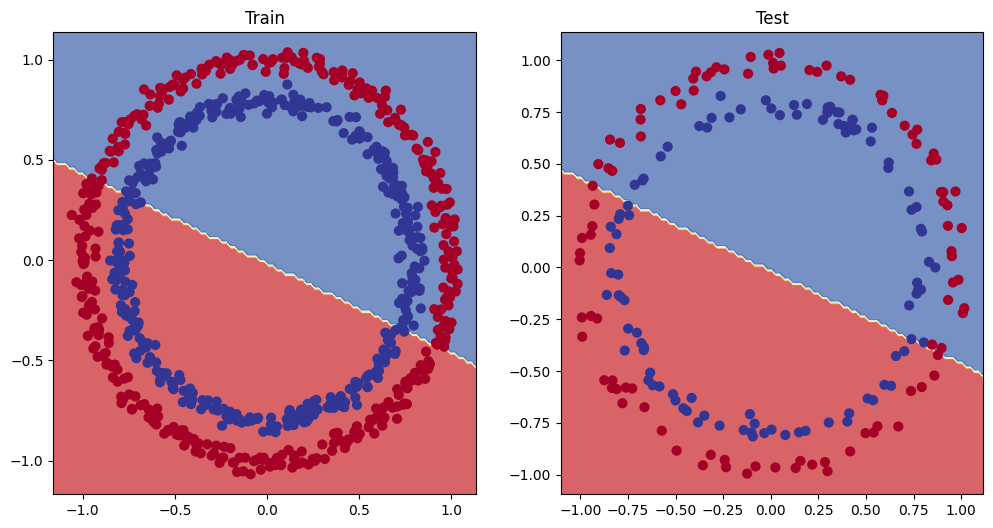

In [34]:
#Plot decesion boundaries 
plt.figure(figsize=(12,6))
plt.subplot(1,2,1)
plt.title("Train")
plot_decision_boundary(model_0,X_train,y_train)
plt.subplot(1,2,2)
plt.title("Test")
plot_decision_boundary(model_0,X_test,y_test)


## 5.Improving our model (From a model's prespective)
* **Add more layers - give the model more chances to learn about the patterns**
* **Add more hidden units**
* **Fit for longer**
* **Changing the activation functions**
* **Change the learning rate** 


### Let's try and improve our model by 
* Adding more hidden units
* increase the number of layers (2-> 3)
* Increase the number of epochs (100 -> 1000) 

change each value one at a time (Expierment tracking)

In [35]:
model_0.state_dict()

OrderedDict([('0.weight',
              tensor([[-0.1569, -0.3018],
                      [-0.0673,  0.1583],
                      [ 0.6054, -0.2429],
                      [-0.6268,  0.0276],
                      [ 0.4955,  0.7066]])),
             ('0.bias', tensor([ 0.6746, -0.2324, -0.3486, -0.4849, -0.1029])),
             ('1.weight',
              tensor([[-0.3166, -0.2168, -0.1315, -0.1040, -0.0533]])),
             ('1.bias', tensor([0.0624]))])

In [36]:
X_train[:5] , y_train[:5]

(tensor([[ 0.6579, -0.4651],
         [ 0.6319, -0.7347],
         [-1.0086, -0.1240],
         [-0.9666, -0.2256],
         [-0.1666,  0.7994]], device='cuda:0'),
 tensor([1., 0., 0., 0., 1.], device='cuda:0'))

In [37]:
class CircleModelv1(nn.Module):
    def __init__(self):
        super().__init__()
        self.layer_1 = nn.Linear(in_features = 2,out_features= 10)#2 in features because
        self.layer_2 = nn.Linear(in_features = 10,out_features= 10)
        self.layer_3 = nn.Linear(in_features = 10,out_features= 1) # 1 and 0 as predcitions

    def forward(self,x):
        return self.layer_3(self.layer_2(self.layer_1(x))) 
        #self.layer_1 executes first and then layer_2 and so on

model_1 = CircleModelv1().to(device)

In [38]:
#Creating a loss fucntion
loss_fn = nn.BCEWithLogitsLoss()
optimizer = torch.optim.SGD(params=model_1.parameters(),
                            lr = 0.1)

In [39]:
model_1.state_dict()

OrderedDict([('layer_1.weight',
              tensor([[ 0.5406,  0.5869],
                      [-0.1657,  0.6496],
                      [-0.1549,  0.1427],
                      [-0.3443,  0.4153],
                      [ 0.6233, -0.5188],
                      [ 0.6146,  0.1323],
                      [ 0.5224,  0.0958],
                      [ 0.3410, -0.0998],
                      [ 0.5451,  0.1045],
                      [-0.3301,  0.1802]], device='cuda:0')),
             ('layer_1.bias',
              tensor([-0.3258, -0.0829, -0.2872,  0.4691, -0.5582, -0.3260, -0.1997, -0.4252,
                       0.0667, -0.6984], device='cuda:0')),
             ('layer_2.weight',
              tensor([[ 0.2856, -0.2686,  0.2441,  0.0526, -0.1027,  0.1954,  0.0493,  0.2555,
                        0.0346, -0.0997],
                      [ 0.0850, -0.0858,  0.1331,  0.2823,  0.1828, -0.1382,  0.1825,  0.0566,
                        0.1606, -0.1927],
                      [-0.3130, -0.122

In [40]:
#Training and testing loops
torch.manual_seed(42)
torch.cuda.manual_seed(42)
epochs = 1000
X_train , y_train = X_train.to(device) , y_train.to(device)
X_test,y_test = X_test.to(device), y_test.to(device)

for epoch in range(epochs):
    model_1.train()
    #forward pass
    y_logits = model_1(X_train).squeeze()
    y_pred = torch.round(torch.sigmoid(y_logits))
    #Calculate the loss
    loss = loss_fn(y_logits,y_train)
    acc = accuracy_fn(y_true = y_train,y_pred = y_pred)
    #Optimizer zero grad
    optimizer.zero_grad()
    #loss backward 
    loss.backward()
    #Optimizer step
    optimizer.step()
    
    model_1.eval()
    with torch.inference_mode():
    #Forward pass
        test_logits = model_1(X_test).squeeze()
        test_pred = torch.round(torch.sigmoid(test_logits))
        
        #Calculate the loss
        test_loss = loss_fn(test_logits,y_test)
        test_acc = accuracy_fn(y_true = y_test, y_pred = test_pred)

        if epoch % 10 == 0:
            print(f"Epoch : {epoch}|Loss : {loss:.5f}|Accuracy : {acc:.2f}%|Test Loss : {test_loss:.5f}|Test Accuracy : {test_acc:.2f}%")

    

Epoch : 0|Loss : 0.69396|Accuracy : 50.88%|Test Loss : 0.69261|Test Accuracy : 51.00%
Epoch : 10|Loss : 0.69369|Accuracy : 50.25%|Test Loss : 0.69270|Test Accuracy : 50.00%
Epoch : 20|Loss : 0.69351|Accuracy : 50.12%|Test Loss : 0.69283|Test Accuracy : 49.50%
Epoch : 30|Loss : 0.69339|Accuracy : 50.50%|Test Loss : 0.69297|Test Accuracy : 48.00%
Epoch : 40|Loss : 0.69329|Accuracy : 50.38%|Test Loss : 0.69310|Test Accuracy : 49.00%
Epoch : 50|Loss : 0.69322|Accuracy : 49.88%|Test Loss : 0.69324|Test Accuracy : 50.00%
Epoch : 60|Loss : 0.69317|Accuracy : 49.38%|Test Loss : 0.69336|Test Accuracy : 51.50%
Epoch : 70|Loss : 0.69312|Accuracy : 49.38%|Test Loss : 0.69348|Test Accuracy : 50.50%
Epoch : 80|Loss : 0.69309|Accuracy : 50.12%|Test Loss : 0.69359|Test Accuracy : 50.00%
Epoch : 90|Loss : 0.69307|Accuracy : 50.50%|Test Loss : 0.69370|Test Accuracy : 48.50%
Epoch : 100|Loss : 0.69305|Accuracy : 50.38%|Test Loss : 0.69379|Test Accuracy : 48.00%
Epoch : 110|Loss : 0.69303|Accuracy : 50.88

In [41]:
def accuracy_fn(y_true,y_pred):
    correct = torch.eq(y_true,)

## 5.1 Preaparing data to see if our model can fit a straight Line
one way to troubleshoot a larger problem is to test out a smaller one

In [42]:
#Create some data
weight = 0.7 
bias = 0.3 

start = 0
end = 1
step = 0.01

X_reg=torch.arange(start,end,step).unsqueeze(dim=1)
y_reg = weight * X_reg + bias

print(len(X_reg))
X_reg[:5] , y_reg[:5]


100


(tensor([[0.0000],
         [0.0100],
         [0.0200],
         [0.0300],
         [0.0400]]),
 tensor([[0.3000],
         [0.3070],
         [0.3140],
         [0.3210],
         [0.3280]]))

In [43]:
#Create train and test splits
train_split =  int(0.8 * len(X_reg))
X_train_reg, y_train_reg = X_reg[:train_split],y_reg[:train_split]
X_test_reg ,y_test_reg = X_reg[train_split:],y_reg[train_split:]

#Check the lenghts
print("X_train : ",len(X_train_reg))
print("y_train : ",len(y_train_reg))
print("X_test : ",len(X_test_reg))
print("y_test : ",len(y_test_reg))

X_train :  80
y_train :  80
X_test :  20
y_test :  20


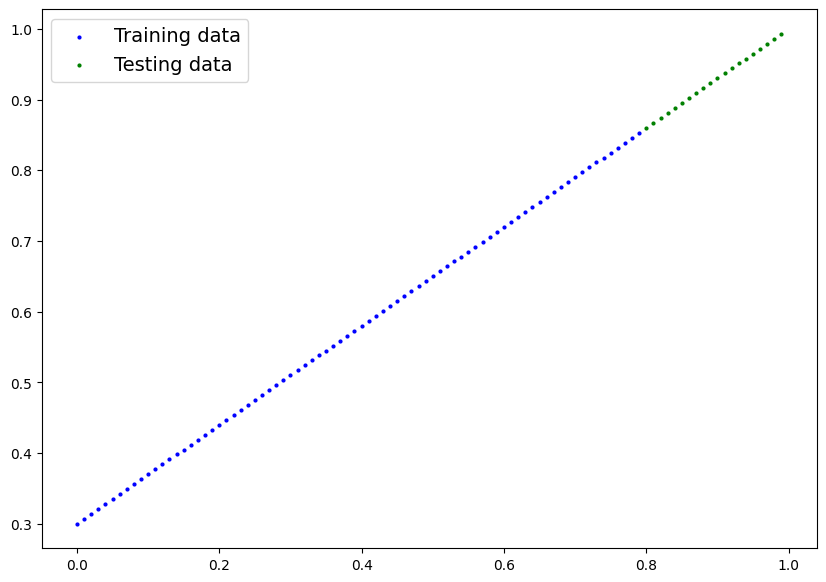

In [44]:
plot_predictions(train_data= X_train_reg,train_labels= y_train_reg,test_data=X_test_reg,test_labels = y_test_reg)

### Adjusting model_1 to fit a straight line

In [45]:
model_2 = nn.Sequential(
    nn.Linear(in_features = 1 ,out_features=10),
    nn.Linear(in_features=  10,out_features=10),
    nn.Linear(in_features=10,out_features=1)
)
model_2

Sequential(
  (0): Linear(in_features=1, out_features=10, bias=True)
  (1): Linear(in_features=10, out_features=10, bias=True)
  (2): Linear(in_features=10, out_features=1, bias=True)
)

In [46]:
#Loss and optimzier
loss_fn = nn.L1Loss()
optimizer = torch.optim.SGD(model_2.parameters(),lr=0.1)

len(y_pred),len(y_train_reg)

(800, 80)

In [47]:

X_train_reg , y_train_reg = X_train_reg.to(device),y_train_reg.to(device)
X_test_reg , y_test_reg = X_test_reg.to(device),y_test_reg.to(device)

In [54]:
#Train the model
torch.manual_seed(42)
torch.cuda.manual_seed(42)  

model_2 = model_2.to(device)
epochs = 1000
for epoch in range(epochs):
    y_pred = model_2(X_train_reg)
    loss = loss_fn(y_pred,y_train_reg)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    #Testing
    with torch.inference_mode():
        test_pred = model_2(X_test_reg)
        test_loss = loss_fn(test_pred,y_test_reg)

    #Print out what is happening
    if epoch % 10 == 0:
        print(f"Epoch : {epoch}| loss : {loss:.5f}|Test_loss:{test_loss:.5f}")

Epoch : 0| loss : 0.06361|Test_loss:0.02465
Epoch : 10| loss : 0.07789|Test_loss:0.02168
Epoch : 20| loss : 0.06605|Test_loss:0.01334
Epoch : 30| loss : 0.06780|Test_loss:0.02416
Epoch : 40| loss : 0.06600|Test_loss:0.02505
Epoch : 50| loss : 0.06745|Test_loss:0.00615
Epoch : 60| loss : 0.07494|Test_loss:0.02545
Epoch : 70| loss : 0.06953|Test_loss:0.01475
Epoch : 80| loss : 0.06993|Test_loss:0.02506
Epoch : 90| loss : 0.05201|Test_loss:0.00558
Epoch : 100| loss : 0.06149|Test_loss:0.01185
Epoch : 110| loss : 0.05579|Test_loss:0.00743
Epoch : 120| loss : 0.05988|Test_loss:0.01636
Epoch : 130| loss : 0.06338|Test_loss:0.02457
Epoch : 140| loss : 0.06087|Test_loss:0.00804
Epoch : 150| loss : 0.06107|Test_loss:0.02004
Epoch : 160| loss : 0.05176|Test_loss:0.01638
Epoch : 170| loss : 0.07503|Test_loss:0.00973
Epoch : 180| loss : 0.05239|Test_loss:0.00737
Epoch : 190| loss : 0.07167|Test_loss:0.02108
Epoch : 200| loss : 0.05039|Test_loss:0.00524
Epoch : 210| loss : 0.05927|Test_loss:0.01642

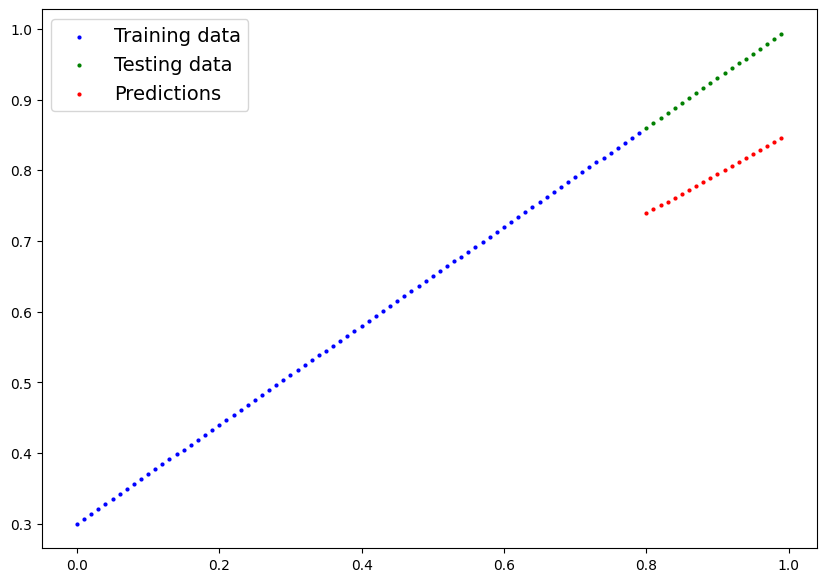

In [56]:
model_2.eval()
with torch.inference_mode():
    y_pred_reg = model_2(X_test_reg)

plot_predictions(train_data = X_train_reg.cpu(),train_labels = y_train_reg.cpu(),test_data = X_test_reg.cpu(),test_labels = y_test_reg.cpu(),predictions= y_pred_reg.cpu())